# Experiment with CatBoost

## Parameters

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [37]:
import os
from enum import Enum
from typing import Dict, List, Optional, Tuple, Union

import catboost
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
from catboost import Pool
from IPython.display import clear_output
from tqdm.auto import tqdm

from utils.datasets import (
    ARTIFACTS_FOLDER,
    ROOT_FOLDER,
    STATIC_FEATURES,
    HydroFiles,
    HydroStaticFeaturesFiles,
    MeteoSeriesFeaturesFiles,
)
from utils.types import TimeRange

%matplotlib inline
os.chdir(ROOT_FOLDER)

In [3]:
# Horizons for forecasting
HISTORY_HORIZON = TimeRange.YEAR
FORECAST_HORIZON = TimeRange.WEEK

# Columns setups
COL_TARGET = "q_mm_day"
COL_GAUGE_ID = "gauge_id"

# Lags
FEATURES_LAGS = None  # Filled below.

In [4]:
# TODO: tnink about aggregation of data instead of horisons.

## Prepare data

In [5]:
SAVE_PATH = ARTIFACTS_FOLDER / "merged_datasets"
merged_datasets = dict()

for filename in tqdm(os.listdir(SAVE_PATH)):
    gauge_id = int(filename.split(".")[0])
    merged_datasets[gauge_id] = pl.read_parquet(SAVE_PATH / filename)

  0%|          | 0/2201 [00:00<?, ?it/s]

### Add lag features

In [6]:
LAG_FEATUES = {
    col: range(1, TimeRange.YEAR + 1)
    for col in next(iter(merged_datasets.values())).columns
    if col != "date"
}
print([name for name in LAG_FEATUES])

['prcp', 't_mean', 't_min', 't_max', 'q_mm_day', 'lvl_sm']


In [7]:
def add_lag_features(
    dataset: pl.DataFrame,
    lag_features: Dict[str, int] = LAG_FEATUES,
) -> pl.LazyFrame:
    """
    Adds lagged columns for specified features in a LazyFrame.
    """
    exprs = []
    ds_columns = list(dataset.schema)
    for col, lag_range in lag_features.items():
        if col in ds_columns:
            for lag in lag_range:
                exprs.append(pl.col(col).shift(lag).alias(f"{col}_lag_{lag}"))
    return dataset.with_columns(exprs)


def add_static_features(
    dataset: pl.LazyFrame,
    static_features: pl.DataFrame,
) -> pl.LazyFrame:
    static_dict = static_features.to_dict()
    for col, value in static_dict.items():
        dataset = dataset.with_columns(pl.lit(value).first().alias(col))
    return dataset

### Создание итогового датасета

In [8]:
hsff = HydroStaticFeaturesFiles()
hsff_ids = set(hsff.get_ids())
hsff = hsff.dataframe.select(STATIC_FEATURES + ["gauge_id"]).collect()

merged_ids = set(merged_datasets.keys())
union_ids = hsff_ids & merged_ids
print(len(hsff_ids), len(merged_ids), len(union_ids))

2203 2201 2201


In [9]:
def create_final_dataset(file_id: int) -> pl.DataFrame:
    res = add_static_features(
        merged_datasets[file_id], hsff.filter(pl.col("gauge_id") == file_id)
    )
    res = add_lag_features(res)
    return res

In [56]:
training_subset = dict()

In [57]:
count = 0
for file_id in tqdm(union_ids):
    if (
        merged_datasets[file_id]
        .filter(pl.any_horizontal(pl.all().is_null()))
        .height
        != 0
    ):
        count += 1
        training_subset[file_id] = create_final_dataset(file_id)

print(count)

  0%|          | 0/2201 [00:00<?, ?it/s]

1129


## Prepare model

In [58]:
from catboost.utils import get_gpu_device_count

MODEL_SAVE_PATH = ARTIFACTS_FOLDER / "models_training"

model_per_lag = [
    catboost.CatBoostRegressor(
        loss_function="MAPE",
        verbose=100,
        save_snapshot=False,
        # snapshot_file=MODEL_SAVE_PATH / f"catboost_{i}_snapshot.cbs",
        snapshot_interval=300,
        random_seed=30,
        # task_type="GPU" if (get_gpu_device_count() > 0) else "CPU",
        # devices="0" if (get_gpu_device_count() > 0) else None,
        # thread_count=-1,
    )
    for i in range(HISTORY_HORIZON)
]

## Train model

In [116]:
import pandas as pd


def Xy_create_and_split(dataset: pl.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    ds = dataset.drop("date")
    X = ds.drop(COL_TARGET)

    COL_TARGET_0 = f"{COL_TARGET}_0"
    y = ds.select(pl.col(COL_TARGET).alias(COL_TARGET_0))
    y = y.with_columns(
        pl.col(COL_TARGET_0).shift(i).alias(f"{COL_TARGET}_{i}")
        for i in range(1, FORECAST_HORIZON)
    )

    X_pd = X.to_pandas()
    y_pd = y.to_pandas()

    mask = y_pd.notna().all(axis=1)

    X_pd = X_pd.loc[mask].reset_index(drop=True)
    y_pd = y_pd.loc[mask].reset_index(drop=True)
    return X_pd, y_pd

In [ ]:
for i, dataset in tqdm(enumerate(training_subset.values())):
    X, y = Xy_create_and_split(dataset)
    for lag, col in tqdm(enumerate(y.columns)):
        training_pool = Pool(X, y[col])
        if i == 0:
            model_per_lag[lag].fit(training_pool)
        else:
            model_per_lag[lag].fit(training_pool, init_model=model_per_lag[lag])
        model_per_lag[lag].save_model(MODEL_SAVE_PATH / f"catboost_{lag}_model.cbm")
        clear_output()
    if i > 8:
        break
    clear_output()

0:	learn: 0.0956885	total: 289ms	remaining: 4m 48s


In [71]:
test_ids = list(training_subset.keys())[11]
ds = training_subset[test_ids]
X, y = Xy_create_and_split(ds)

y_pred = list()

for lag, col in tqdm(enumerate(y.columns)):
    predict_pool = Pool(X)
    y_pred.append(model_per_lag[lag].predict(predict_pool))

0it [00:00, ?it/s]

In [ ]:
import numpy as np

y_pred = np.array(y_pred)

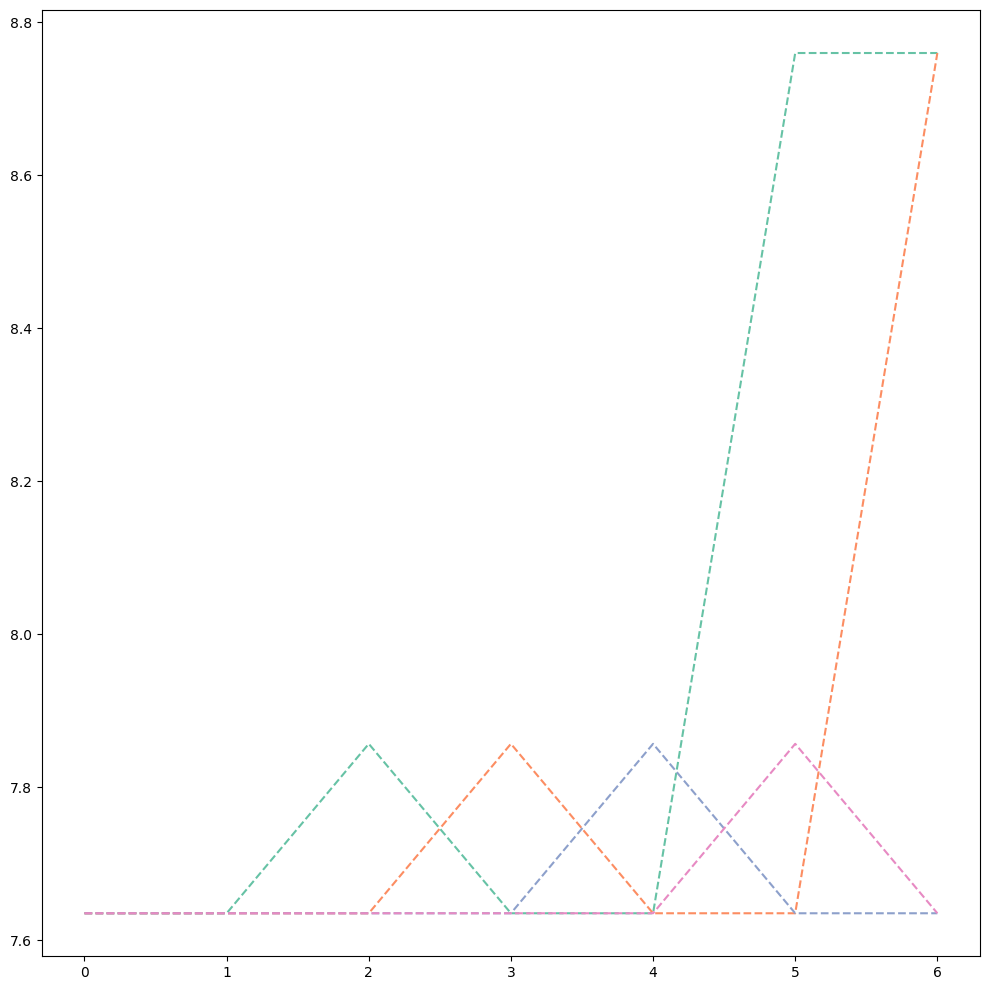

In [113]:
plt.figure(figsize=(10, 10))
colors = sns.color_palette("Set2")

for i, row in enumerate(y.iloc[:4].iterrows()):
    plt.plot(row[1].tolist(), color=colors[i], linestyle="--")
    pass

for i, row in enumerate(y_pred.T[:4, :]):
    # plt.plot(row, color=colors[i])
    pass

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split


def train_test_valid_split()